In [24]:
import pandas as pd
import numpy as np 
from keras.models import Sequential
from keras import layers, ops 
import keras
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tf2onnx
import os
import subprocess
import sys 

In [5]:
X = np.load("../Data/X_train.npy")
Y = np.load("../Data/Y_train.npy")

print(X.shape)
print(Y.shape)

(20631, 14)
(20631,)


In [6]:
def AutoEncoder(X, input_dim, latent_dim, output_dim):
    model = Sequential([
        # Encoding phase
        keras.Input((input_dim, )),
        layers.Dense(16, name = 'Enc_layer1', kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(8, name = 'Enc_layer2', kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(latent_dim, name = 'Latent_Space', kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)), 
        layers.LeakyReLU(alpha = 0.01), 

        #Decoding phase
        layers.Dense(8, name = "dec_dense1", kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(16, name = "dec_dense2", kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1)),
        layers.LeakyReLU(alpha = 0.01),
        layers.Dense(output_dim, name="output_layer", kernel_initializer= 'he_normal', kernel_regularizer = keras.regularizers.l2(0.1))
    ])
    # model.summary()
    return model

In [7]:
def train(X, epochs, batch_size): 
    input_dim = X.shape[1]
    latent_dim = 4
    output_dim = X.shape[1]
    model = AutoEncoder(X, input_dim, latent_dim, output_dim)

    model.compile(optimizer = keras.optimizers.Adam(learning_rate = 0.0005), loss = 'mse')

    early_stop = EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)
    model.fit(X, 
              X,
              epochs = epochs,
              batch_size = batch_size,
              verbose = 1,
              shuffle = True,
              callbacks = [early_stop]
             )

    X_decoded = model.predict(X)

    return X_decoded, model
    

In [8]:
X_decoded, model = train(X, epochs=100, batch_size=256)

Epoch 1/100


/Users/shivaram/telemetry-anomaly-detector/.venv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 448us/step - loss: 13.0021 
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - loss: 11.1463
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - loss: 9.6135
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 8.2924
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - loss: 7.1520
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 336us/step - loss: 6.1669
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 5.3165
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step - loss: 4.5824
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 3.9481
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 346us/step - loss: 3.3993
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - loss: 2.9245
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 347us/step - loss: 2.5137
Epoch 13/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 2.1587
Epoch 14/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 334us/step - loss: 1.8520
Epoch 15/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/ste

645/645 ━━━━━━━━━━━━━━━━━━━━ 0s 166us/step


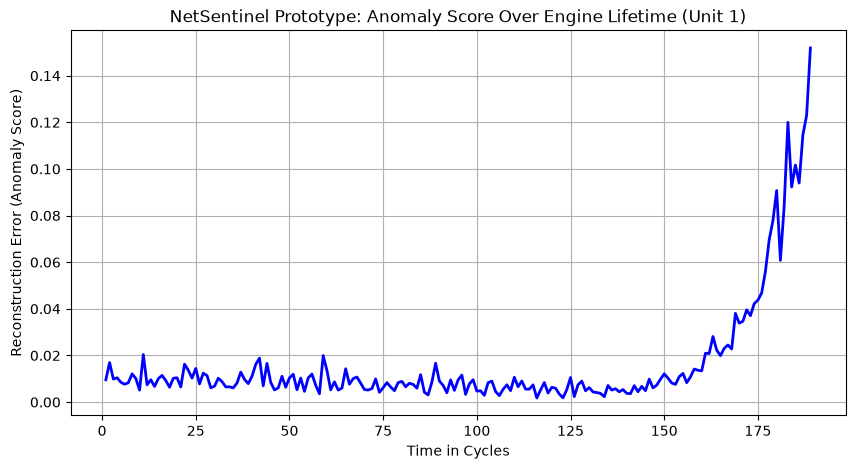

In [12]:
X_pred = model.predict(X)
reconstruction_errors = np.mean(np.square(X - X_pred), axis=1)

metadata = pd.read_csv('../Data/metadata.csv')

metadata['anomaly_score'] = reconstruction_errors

engine_1 = metadata[metadata['unit_number'] == 4].sort_values('time_in_cycles')

plt.figure(figsize=(10, 5))
plt.plot(engine_1['time_in_cycles'], engine_1['anomaly_score'], color='blue', linewidth=2)
plt.title("NetSentinel Prototype: Anomaly Score Over Engine Lifetime (Unit 1)")
plt.xlabel("Time in Cycles")
plt.ylabel("Reconstruction Error (Anomaly Score)")
plt.grid(True)
plt.show()

In [18]:
unit_data = metadata[metadata['unit_number'] == 1]
unit_data

,unit_number,time_in_cycles,anomaly_score
0,1,1,0.016208
1,1,2,0.011673
2,1,3,0.016093
3,1,4,0.025261
4,1,5,0.010540
...,...,...,...
187,1,188,0.075567
188,1,189,0.086527
189,1,190,0.092464
190,1,191,0.074623


In [21]:
error = unit_data['anomaly_score']
error

0      0.016208
1      0.011673
2      0.016093
3      0.025261
4      0.010540
         ...   
187    0.075567
188    0.086527
189    0.092464
190    0.074623
191    0.089875
Name: anomaly_score, Length: 192, dtype: float64

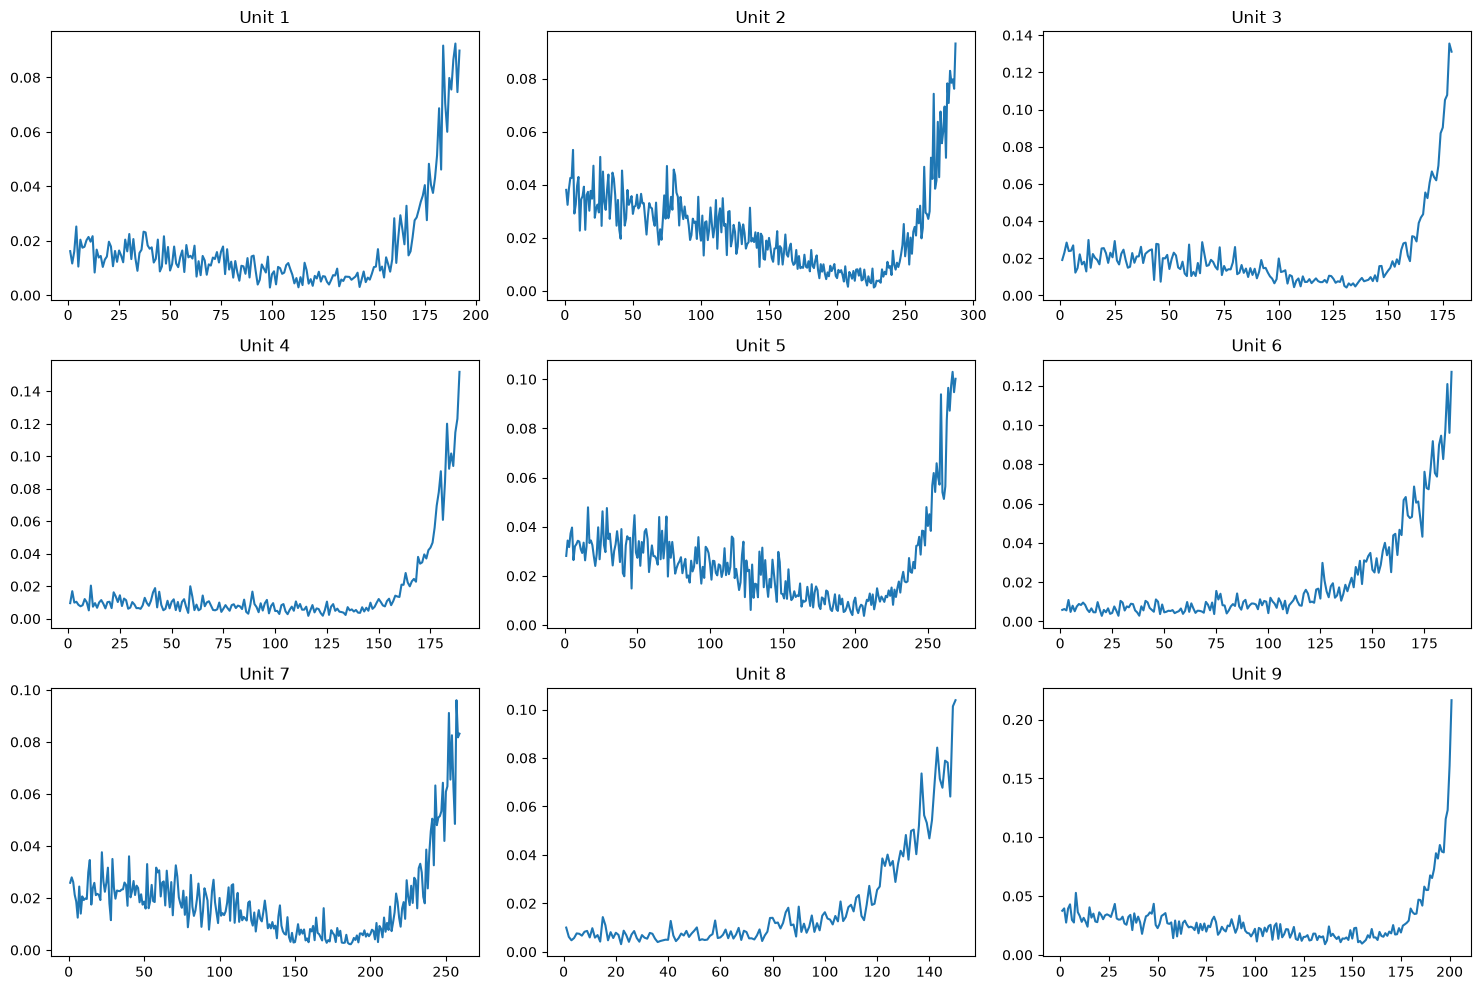

In [22]:
df = pd.read_csv("../Data/dataset.csv")
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for idx, unit in enumerate(df['unit_number'].unique()[:9]):
    ax = axes[idx//3, idx%3]
    unit_data = metadata[metadata['unit_number'] == unit]
    errors_for_unit = unit_data['anomaly_score']
    ax.plot(unit_data['time_in_cycles'], errors_for_unit)
    ax.set_title(f'Unit {unit}')
plt.tight_layout()

In [23]:
model.save("../Model/AutoEncoder.keras")
print("Model saved sucessfully!")

Model saved sucessfully!


In [25]:
if not os.path.exists('../Model/model/tf_saved_model'):
    model.export('../Model/model/tf_saved_model')
    print("SavedModel artifact generated.")
else:
    print("Found existing SavedModel artifact from your last run. Perfect.")

# sys.executable forces the script to use the precise .venv Python 3.11 interpreter where tf2onnx lives
onnx_command = f"{sys.executable} -m tf2onnx.convert --saved-model ../Model/model/tf_saved_model --output ../Model/model/telemetry_autoencoder.onnx --opset 15"

# Run the terminal command safely
result = subprocess.run(onnx_command.split(), capture_output=True, text=True)

# 3. Verify the final result
if result.returncode == 0:
    print("\nSUCCESS! ")
else:
    print("\n Error ")
    print(result.stderr)

INFO:tensorflow:Assets written to: ../Model/model/tf_saved_model/assets


INFO:tensorflow:Assets written to: ../Model/model/tf_saved_model/assets


Saved artifact at '../Model/model/tf_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 14), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 14), dtype=tf.float32, name=None)
Captures:
  4538491024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4538487184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900211984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900220432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900220624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900220240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4538492944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900221968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900222160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900222736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4900221776: TensorSpec(shape=(), dtype=tf.resource, name=No